## Model Interpretability & Explainability

This notebook answers the question: *why* does the model make each prediction?

A model that achieves decent accuracy on a test set is not sufficient on its own. We need to verify that it is learning genuine linguistic patterns (words like *horrible*, *amazing*, *side effects*) rather than exploiting spurious artefacts in the data. This is especially important for a medical domain where model behaviour must be trustworthy.

We address interpretability through three lenses:

1. **Per-class performance breakdown** — classification report and confusion matrix analysis
2. **LIME analysis** — local word-level explanations for individual predictions
3. **Error analysis** — understanding the systematic failure modes of the model

### Setup: Install Dependencies

In [ ]:
import subprocess
subprocess.run(['pip', 'install', 'lime', '--quiet'], check=True)
print("Dependencies ready.")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.2 requires numpy<2.0.0,>=1.26.0; python_version >= "3.12", but you have numpy 2.4.6 which is incompatible.


Dependencies ready.


### Load All Assets

In [ ]:
import os
import html
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import TextVectorization
from sklearn.metrics import classification_report, confusion_matrix
from lime.lime_text import LimeTextExplainer

# Paths
MODEL_PATH    = os.path.join('..', 'models', 'bidi_lstm_balanced_model.keras')
VOCAB_PATH    = os.path.join('..', 'models', 'vectorizer_vocabulary.json')
DATASET_PATH  = os.path.join('..', 'dataset', 'archive.zip')
FIGURES_DIR   = os.path.join('..', 'outputs', 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# Loading model
print("Loading Bi-LSTM model...")
model = load_model(MODEL_PATH)

# Rebuilding vectorizer
print("Rebuilding vectorizer from saved vocabulary...")
with open(VOCAB_PATH, 'r', encoding='utf-8') as f:
    saved_vocabulary = json.load(f)

inference_vectorizer = TextVectorization(
    max_tokens=10000,
    output_mode='int',
    output_sequence_length=150,
    vocabulary=saved_vocabulary
)

# Text cleaning 
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = html.unescape(text)
    text = text.lower()
    text = text.strip()
    return text

print("\nAll assets loaded successfully.")

2026-06-15 14:21:44.549344: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading Bi-LSTM model...
Rebuilding vectorizer from saved vocabulary...

All assets loaded successfully.


### Generate Predictions on the Full Test Set
We run inference on all test rows once here. The results are reused for the classification report, confusion matrix, and error analysis — no repeated forward passes needed.

In [ ]:
import zipfile

print("Loading test data...")
with zipfile.ZipFile(DATASET_PATH, 'r') as z:
    with z.open('drugsComTest_raw.csv') as f:
        df_test = pd.read_csv(f)

df_test = df_test.dropna(subset=['review', 'rating']).reset_index(drop=True)
print(f"Test set size: {len(df_test):,} reviews")

# Cleaning and vectorizing
print("Running model predictions on full test set (this takes ~1-2 minutes)...")
cleaned_reviews   = df_test['review'].apply(clean_text)
vectorized_inputs = inference_vectorizer(cleaned_reviews.values).numpy()
raw_probabilities = model.predict(vectorized_inputs, batch_size=256, verbose=1)

# Shifting predictions back to human-readable 1–10 scale
y_pred = np.argmax(raw_probabilities, axis=1) + 1
y_true = df_test['rating'].values.astype(int)

print(f"\nPredictions generated for {len(y_pred):,} reviews.")

Loading test data...
Test set size: 53,766 reviews
Running model predictions on full test set (this takes ~1-2 minutes)...
211/211 ━━━━━━━━━━━━━━━━━━━━ 31s 145ms/step

Predictions generated for 53,766 reviews.


---
## Section 1: Per-Class Performance Breakdown
The classification report breaks down precision, recall, and F1 per rating class. This is more informative than a single accuracy number because our dataset is heavily imbalanced — rating 10 accounts for a disproportionate share of samples.

In [3]:
target_names = [f"Rating {i}" for i in range(1, 11)]

print("=" * 65)
print("        CLASSIFICATION REPORT — BALANCED BI-LSTM MODEL")
print("=" * 65)
print(classification_report(y_true, y_pred, target_names=target_names))

# Overall accuracy
overall_acc = np.mean(y_pred == y_true)
# Mean Absolute Error — useful here because rating is ordinal (1 is closer to 2 than to 10)
mae = np.mean(np.abs(y_pred - y_true))

print(f"Overall Accuracy : {overall_acc:.4f} ({overall_acc*100:.2f}%)")
print(f"Mean Absolute Error (MAE): {mae:.4f} rating points")
print()
print("Interpretation: MAE measures how far off predictions are on average.")
print("An MAE of ~1.5 means predictions are typically within 1-2 stars of truth.")

        CLASSIFICATION REPORT — BALANCED BI-LSTM MODEL
              precision    recall  f1-score   support

    Rating 1       0.58      0.55      0.56      7299
    Rating 2       0.20      0.20      0.20      2334
    Rating 3       0.17      0.18      0.18      2205
    Rating 4       0.16      0.30      0.21      1659
    Rating 5       0.17      0.31      0.22      2710
    Rating 6       0.13      0.27      0.18      2119
    Rating 7       0.15      0.20      0.17      3091
    Rating 8       0.23      0.14      0.17      6156
    Rating 9       0.34      0.19      0.24      9177
   Rating 10       0.64      0.62      0.63     17016

    accuracy                           0.38     53766
   macro avg       0.28      0.30      0.28     53766
weighted avg       0.41      0.38      0.39     53766

Overall Accuracy : 0.3834 (38.34%)
Mean Absolute Error (MAE): 1.5185 rating points

Interpretation: MAE measures how far off predictions are on average.
An MAE of ~1.5 means predictions 

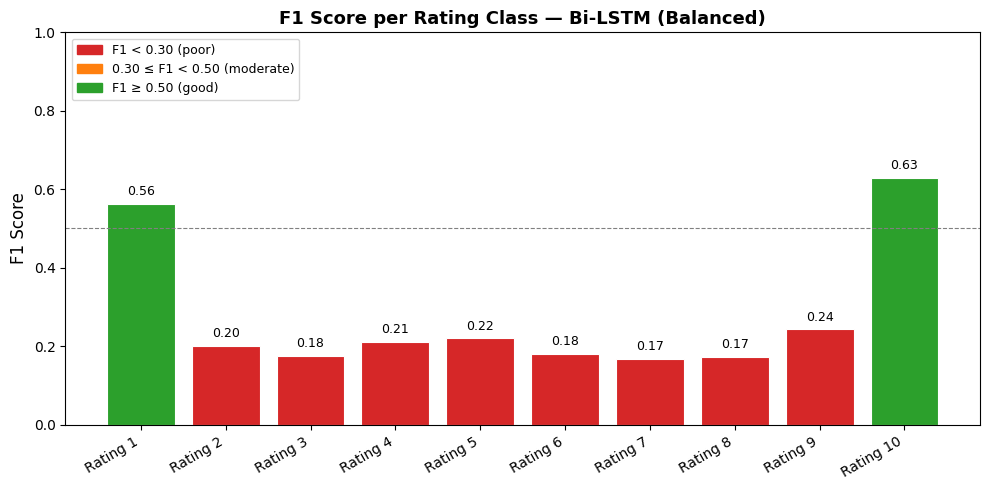

Figure saved to outputs/figures/f1_per_class.png


In [4]:
# ── Visualize F1 score per rating class ────────────────────────────────────
from sklearn.metrics import f1_score

f1_per_class = f1_score(y_true, y_pred, average=None, labels=list(range(1, 11)))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d62728' if f < 0.3 else '#ff7f0e' if f < 0.5 else '#2ca02c' for f in f1_per_class]
bars = ax.bar(range(1, 11), f1_per_class, color=colors, edgecolor='white', linewidth=0.8)

ax.set_xticks(range(1, 11))
ax.set_xticklabels([f"Rating {i}" for i in range(1, 11)], rotation=30, ha='right')
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score per Rating Class — Bi-LSTM (Balanced)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='F1 = 0.5 threshold')
ax.legend()

# Annotate each bar with its value
for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)

patches = [
    mpatches.Patch(color='#d62728', label='F1 < 0.30 (poor)'),
    mpatches.Patch(color='#ff7f0e', label='0.30 ≤ F1 < 0.50 (moderate)'),
    mpatches.Patch(color='#2ca02c', label='F1 ≥ 0.50 (good)')
]
ax.legend(handles=patches, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'f1_per_class.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/figures/f1_per_class.png")

---
## Section 2: Confusion Matrix Analysis
The confusion matrix shows exactly where the model confuses one class for another. We normalize it by true label so each row sums to 1 — this makes it easy to see recall per class regardless of class size.

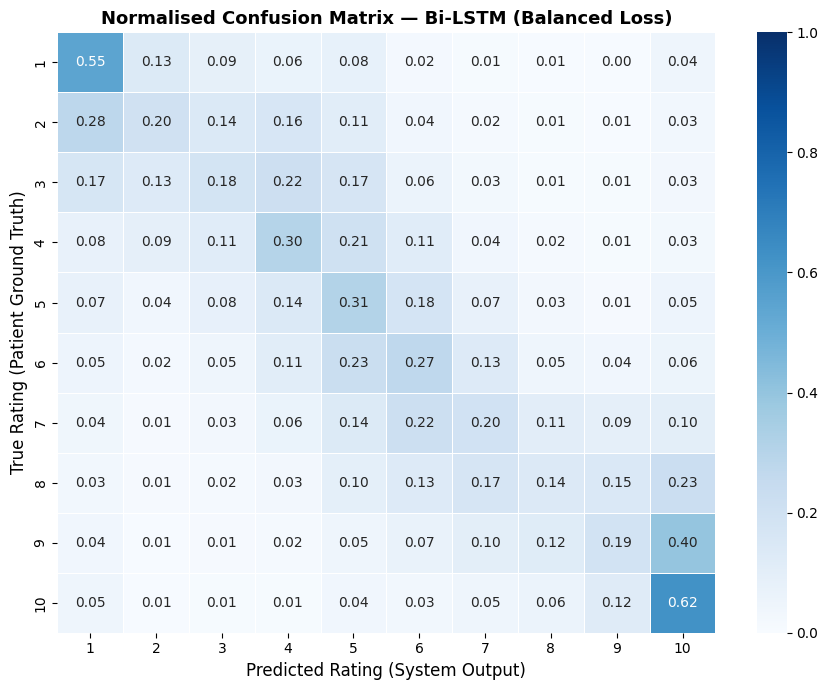

Figure saved to outputs/figures/confusion_matrix_normalised.png


In [6]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(1, 11)))
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=range(1, 11),
    yticklabels=range(1, 11),
    linewidths=0.4,
    ax=ax,
    vmin=0, vmax=1
)
ax.set_xlabel('Predicted Rating (System Output)', fontsize=12)
ax.set_ylabel('True Rating (Patient Ground Truth)', fontsize=12)
ax.set_title('Normalised Confusion Matrix — Bi-LSTM (Balanced Loss)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'confusion_matrix_normalised.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to outputs/figures/confusion_matrix_normalised.png")

In [7]:
# ── Key observations from the confusion matrix ─────────────────────────────
print("KEY CONFUSION MATRIX OBSERVATIONS")
print("=" * 50)

for true_rating in range(1, 11):
    row_idx = true_rating - 1
    total = cm[row_idx].sum()
    correct = cm[row_idx][row_idx]
    recall = correct / total if total > 0 else 0
    # Most common wrong prediction
    row_copy = cm[row_idx].copy()
    row_copy[row_idx] = 0  # zero out correct
    most_confused_with = np.argmax(row_copy) + 1
    confused_count = row_copy[most_confused_with - 1]
    print(f"Rating {true_rating:2d}: recall={recall:.2f} | "
          f"most confused with Rating {most_confused_with} "
          f"({confused_count:,} times, {confused_count/total*100:.1f}% of true-{true_rating} reviews)")

KEY CONFUSION MATRIX OBSERVATIONS
Rating  1: recall=0.55 | most confused with Rating 2 (977 times, 13.4% of true-1 reviews)
Rating  2: recall=0.20 | most confused with Rating 1 (653 times, 28.0% of true-2 reviews)
Rating  3: recall=0.18 | most confused with Rating 4 (480 times, 21.8% of true-3 reviews)
Rating  4: recall=0.30 | most confused with Rating 5 (342 times, 20.6% of true-4 reviews)
Rating  5: recall=0.31 | most confused with Rating 6 (483 times, 17.8% of true-5 reviews)
Rating  6: recall=0.27 | most confused with Rating 5 (481 times, 22.7% of true-6 reviews)
Rating  7: recall=0.20 | most confused with Rating 6 (679 times, 22.0% of true-7 reviews)
Rating  8: recall=0.14 | most confused with Rating 10 (1,386 times, 22.5% of true-8 reviews)
Rating  9: recall=0.19 | most confused with Rating 10 (3,625 times, 39.5% of true-9 reviews)
Rating 10: recall=0.62 | most confused with Rating 9 (2,074 times, 12.2% of true-10 reviews)


---
## Section 3: LIME Analysis

LIME (Local Interpretable Model-Agnostic Explanations) explains individual predictions by:
1. Taking one review and generating ~500 perturbed versions (randomly masking words)
2. Getting model predictions for all perturbed versions
3. Fitting a simple linear model locally to identify which words most influenced the prediction

Words shown in **green** push the prediction toward the predicted rating. Words in **red** push against it.

We analyse three review types: clearly positive, clearly negative, and ambiguous/mixed.

In [9]:
# ── LIME prediction function ────────────────────────────────────────────────
# LIME passes many perturbed text variants to this function.
# It must accept a list of strings and return (n_samples, n_classes) probabilities.

def predict_fn(texts):
    cleaned   = [clean_text(t) for t in texts]
    vectorized = inference_vectorizer(cleaned).numpy()
    probas    = model.predict(vectorized, verbose=0, batch_size=64)
    return probas   # shape: (n, 10) — softmax over ratings 1–10 (shifted 0–9)

# ── Set up the explainer ────────────────────────────────────────────────────
class_names = [f"Rating {i}" for i in range(1, 11)]

explainer = LimeTextExplainer(class_names=class_names)

print("LIME explainer ready.")
print("Note: each explain_instance call generates ~500 forward passes — takes 15-30 seconds.")

LIME explainer ready.
Note: each explain_instance call generates ~500 forward passes — takes 15-30 seconds.


In [10]:
# ── Helper: run LIME on one review and save the plot ───────────────────────
def explain_review(review_text, filename, num_features=12, num_samples=500):
    """
    Runs LIME on a single review, prints the prediction, and saves a bar chart
    showing the word-level contributions toward the predicted class.
    """
    cleaned = clean_text(review_text)
    vec     = inference_vectorizer([cleaned]).numpy()
    probs   = model.predict(vec, verbose=0)[0]
    
    predicted_class_idx = int(np.argmax(probs))     # 0-indexed
    predicted_rating    = predicted_class_idx + 1   # human-readable 1–10
    confidence          = probs[predicted_class_idx]

    print(f"Review   : \"{review_text[:120]}...\"" if len(review_text) > 120 else f"Review: \"{review_text}\"")
    print(f"Predicted Rating : {predicted_rating} / 10  (confidence: {confidence:.1%})")
    print(f"Running LIME with {num_samples} perturbations...")

    exp = explainer.explain_instance(
        text_instance  = cleaned,
        classifier_fn  = predict_fn,
        labels         = [predicted_class_idx],
        num_features   = num_features,
        num_samples    = num_samples
    )

    # Extract word weights for the predicted class
    word_weights = exp.as_list(label=predicted_class_idx)
    words, weights = zip(*word_weights) if word_weights else ([], [])

    # Sort by absolute importance
    sorted_pairs = sorted(zip(words, weights), key=lambda x: abs(x[1]))
    words_sorted, weights_sorted = zip(*sorted_pairs) if sorted_pairs else ([], [])

    colors = ['#2ca02c' if w > 0 else '#d62728' for w in weights_sorted]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(words_sorted, weights_sorted, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('LIME Weight (contribution toward predicted class)', fontsize=11)
    ax.set_title(
        f'LIME Explanation — Predicted Rating: {predicted_rating}/10 (conf: {confidence:.1%})',
        fontsize=12, fontweight='bold'
    )

    green_patch = mpatches.Patch(color='#2ca02c', label='Supports this prediction')
    red_patch   = mpatches.Patch(color='#d62728', label='Works against this prediction')
    ax.legend(handles=[green_patch, red_patch], loc='lower right', fontsize=9)

    plt.tight_layout()
    save_path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure saved to outputs/figures/{filename}\n")
    
    return exp, predicted_rating

print("Helper function defined.")

Helper function defined.


#### LIME Example 1: Clearly Positive Review

Review   : "This medication completely changed my life. Within two days, my chronic symptoms vanished completely. No side effects at..."
Predicted Rating : 10 / 10  (confidence: 78.2%)
Running LIME with 500 perturbations...


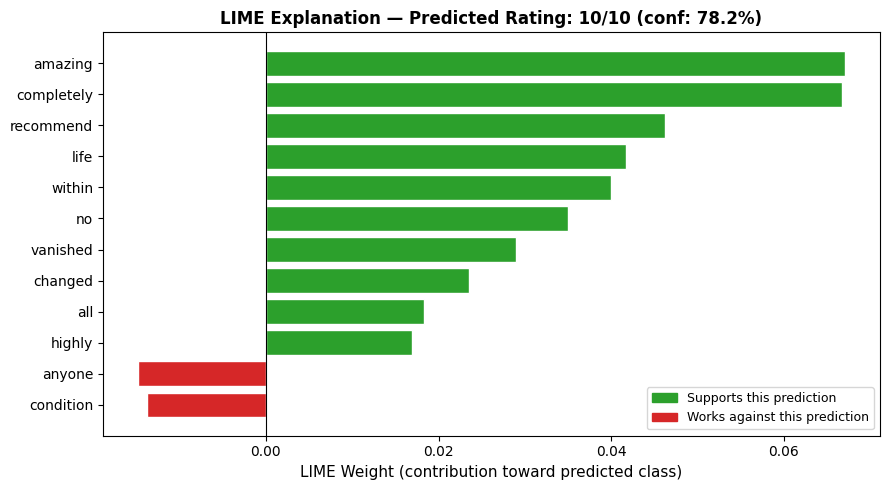

Figure saved to outputs/figures/lime_positive_review.png



In [11]:
review_positive = (
    "This medication completely changed my life. Within two days, my chronic symptoms "
    "vanished completely. No side effects at all! I feel amazing and would highly recommend "
    "this to anyone suffering from the same condition."
)

exp_positive, pred_positive = explain_review(
    review_positive,
    filename='lime_positive_review.png'
)

#### LIME Example 2: Clearly Negative Review

Review   : "Absolutely horrible experience. I suffered terrible nausea and severe headaches within an hour of taking this medication..."
Predicted Rating : 1 / 10  (confidence: 94.6%)
Running LIME with 500 perturbations...


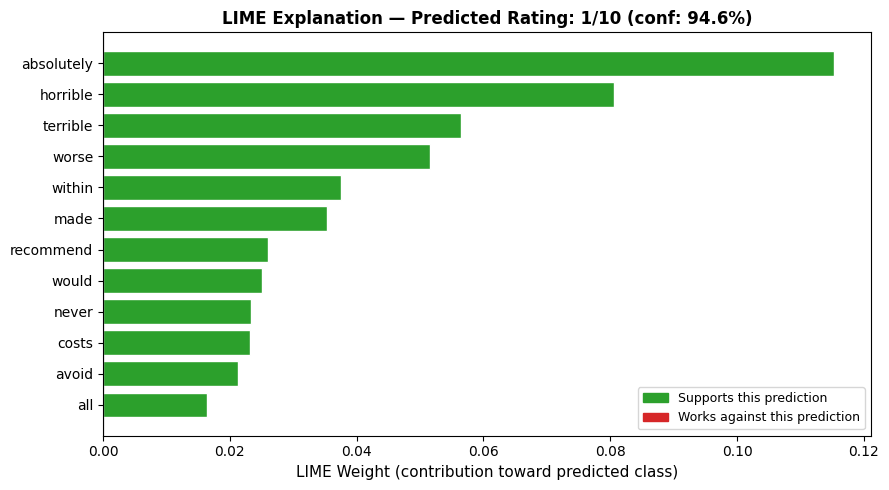

Figure saved to outputs/figures/lime_negative_review.png



In [12]:
review_negative = (
    "Absolutely horrible experience. I suffered terrible nausea and severe headaches "
    "within an hour of taking this medication. It made everything worse and I would "
    "never recommend this to anyone. Avoid at all costs."
)

exp_negative, pred_negative = explain_review(
    review_negative,
    filename='lime_negative_review.png'
)

#### LIME Example 3: Ambiguous / Mixed Review

Review   : "The drug works well enough to manage the pain, but the fatigue makes it almost impossible to stay awake during work hour..."
Predicted Rating : 5 / 10  (confidence: 21.1%)
Running LIME with 500 perturbations...


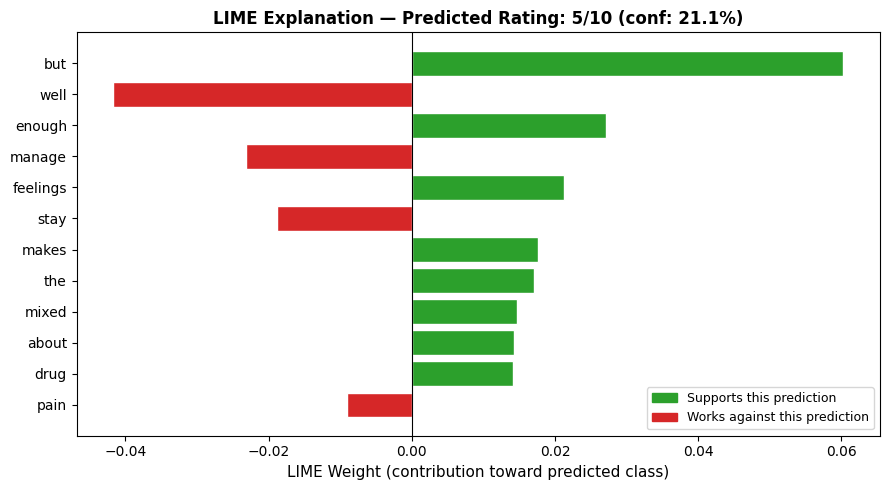

Figure saved to outputs/figures/lime_mixed_review.png



In [13]:
review_mixed = (
    "The drug works well enough to manage the pain, but the fatigue makes it almost "
    "impossible to stay awake during work hours. I have mixed feelings about continuing "
    "with this treatment."
)

exp_mixed, pred_mixed = explain_review(
    review_mixed,
    filename='lime_mixed_review.png'
)

#### LIME Example 4: A Real Test Set Review That the Model Got Wrong
We pick a case where the model made a large error to see what went wrong at the word level.

In [14]:
# Find a real test review with a large prediction error (|true - pred| >= 5)
df_test['predicted_rating'] = y_pred
df_test['abs_error']        = np.abs(df_test['rating'] - df_test['predicted_rating'])

# Pick one where the model was very wrong and the review is long enough to be interesting
large_errors = df_test[
    (df_test['abs_error'] >= 5) &
    (df_test['review'].str.split().apply(len) > 30)
].head(10)

print(f"Found {len(large_errors)} reviews with |error| >= 5 and >30 words.")
print()

# Take the first candidate
error_row = large_errors.iloc[0]
print(f"True rating      : {int(error_row['rating'])}")
print(f"Predicted rating : {int(error_row['predicted_rating'])}")
print(f"Review           : {error_row['review'][:300]}")

Found 10 reviews with |error| >= 5 and >30 words.

True rating      : 1
Predicted rating : 10
Review           : "After a few days and it &quot;kicked in,&quot; every noise in the house would make me jump, pictures on TV would feel as if they were 3-D and make me jump, and I literally felt like my skin was crawling, moving, and melding to things, such as blankets. My mind focused and keyed in on every piece of


Review   : ""After a few days and it &quot;kicked in,&quot; every noise in the house would make me jump, pictures on TV would feel a..."
Predicted Rating : 10 / 10  (confidence: 19.8%)
Running LIME with 500 perturbations...


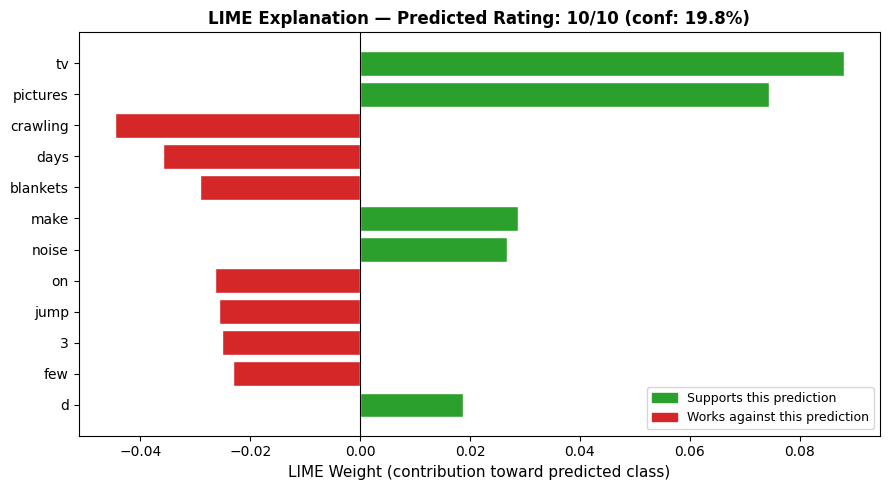

Figure saved to outputs/figures/lime_error_case.png

True rating was  : 1 — model predicted: 10
The LIME plot above shows which words led to the incorrect prediction.


In [15]:
exp_error, pred_error = explain_review(
    error_row['review'],
    filename='lime_error_case.png'
)

print(f"True rating was  : {int(error_row['rating'])} — model predicted: {pred_error}")
print("The LIME plot above shows which words led to the incorrect prediction.")

---
## Section 4: Error Analysis

We systematically analyse what types of mistakes the model makes most often. The confusion matrix already showed that the model struggles with middle ratings (4–7). Here we go deeper — showing concrete examples and identifying linguistic patterns that cause failures.

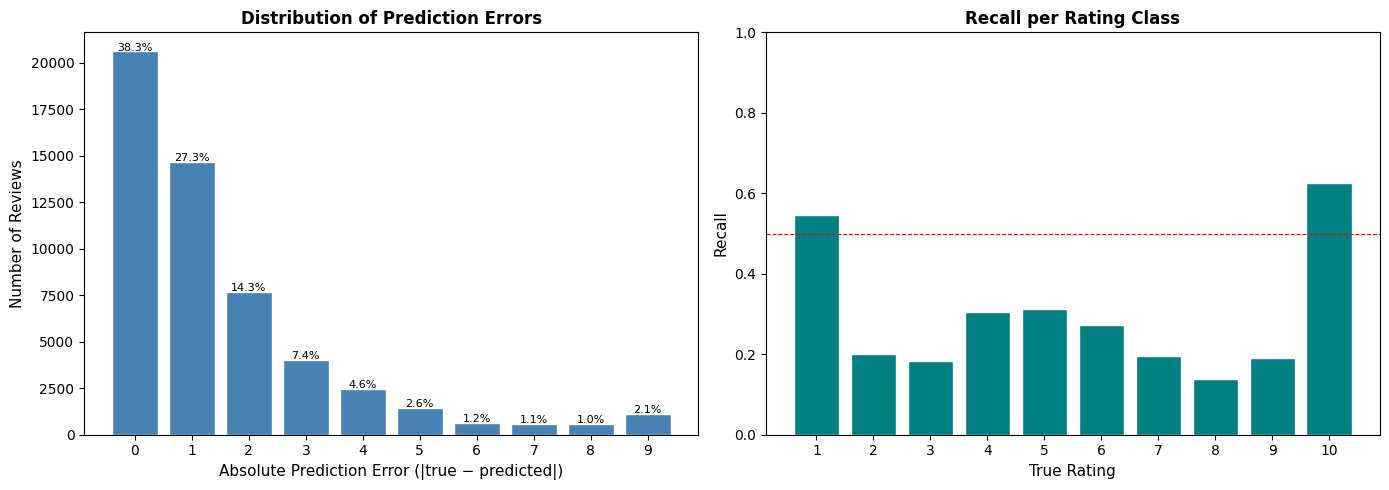

ERROR SUMMARY
  Exact match (|err| = 0) : 38.34%
  Within 1 star           : 65.59%
  Within 2 stars          : 79.90%
  Off by 5+ stars         : 8.10%


In [16]:
# ── Error distribution ──────────────────────────────────────────────────────
error_distribution = pd.Series(np.abs(y_pred - y_true)).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: error distribution
axes[0].bar(error_distribution.index, error_distribution.values,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Absolute Prediction Error (|true − predicted|)', fontsize=11)
axes[0].set_ylabel('Number of Reviews', fontsize=11)
axes[0].set_title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(0, 10))

# Annotate with percentage
total = len(y_pred)
for x, y in zip(error_distribution.index, error_distribution.values):
    axes[0].text(x, y + 50, f'{y/total*100:.1f}%', ha='center', fontsize=8)

# Right: recall per rating class as a bar chart
recall_per_class = [cm[i, i] / cm[i].sum() for i in range(10)]
axes[1].bar(range(1, 11), recall_per_class, color='teal', edgecolor='white')
axes[1].set_xlabel('True Rating', fontsize=11)
axes[1].set_ylabel('Recall', fontsize=11)
axes[1].set_title('Recall per Rating Class', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(1, 11))
axes[1].set_ylim(0, 1)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'error_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print key stats
exact_match  = np.mean(y_pred == y_true)
within_one   = np.mean(np.abs(y_pred - y_true) <= 1)
within_two   = np.mean(np.abs(y_pred - y_true) <= 2)
large_errors_pct = np.mean(np.abs(y_pred - y_true) >= 5)

print("ERROR SUMMARY")
print(f"  Exact match (|err| = 0) : {exact_match:.2%}")
print(f"  Within 1 star           : {within_one:.2%}")
print(f"  Within 2 stars          : {within_two:.2%}")
print(f"  Off by 5+ stars         : {large_errors_pct:.2%}")

In [17]:
# ── Middle-rating failure analysis ─────────────────────────────────────────
# Reviews with true ratings 4-6 that the model predicted as 1 or 10
# This is the most interesting failure mode shown in the confusion matrix.

print("MIDDLE-RATING MISCLASSIFICATION EXAMPLES")
print("(True rating 4-6, predicted as 1 or 10)")
print("=" * 65)

middle_failures = df_test[
    (df_test['rating'].between(4, 6)) &
    (df_test['predicted_rating'].isin([1, 10]))
].sample(n=min(5, len(df_test)), random_state=42)

for _, row in middle_failures.iterrows():
    print(f"\nTrue: {int(row['rating'])}  |  Predicted: {int(row['predicted_rating'])}")
    print(f"Drug: {row.get('drugName', 'N/A')}")
    print(f"Review: {str(row['review'])[:300]}")
    print("-" * 65)

MIDDLE-RATING MISCLASSIFICATION EXAMPLES
(True rating 4-6, predicted as 1 or 10)

True: 5  |  Predicted: 10
Drug: Lamotrigine
Review: "I have taken lamotrigine for about 5 weeks.  I tapered from nefazodone to lamotrigine over the course of 3 weeks.  I am currently at 100 mg of lamotrigine.  I was feeling better than I have ever felt in my entire life for about 2 weeks, now I am back to where I was before.  No, I was not feeling ma
-----------------------------------------------------------------

True: 4  |  Predicted: 1
Drug: Sertraline
Review: "This medicine managed the depression and anxiety but not the Trichotillomania."
-----------------------------------------------------------------

True: 4  |  Predicted: 1
Drug: Etonogestrel
Review: "I absolutely loved it at first then all of the sudden NON STOP bleeding, literally non STOP for the past 4 months. Clots of blood at this point. I am getting this removed immediately."
--------------------------------------------------------------

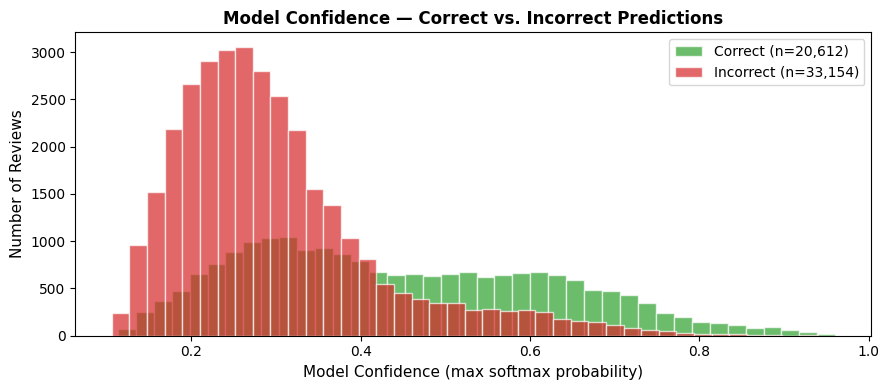

Mean confidence when correct   : 0.446
Mean confidence when incorrect : 0.299

If mean confidence is similar for correct and incorrect predictions,
the model is overconfident (poorly calibrated).


In [18]:
# ── Confidence on correct vs. incorrect predictions ────────────────────────
# A well-calibrated model should be less confident when it's wrong.

max_probs        = np.max(raw_probabilities, axis=1)  # confidence on each prediction
correct_mask     = (y_pred == y_true)

correct_conf     = max_probs[correct_mask]
incorrect_conf   = max_probs[~correct_mask]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(correct_conf,   bins=40, alpha=0.7, label=f'Correct (n={correct_mask.sum():,})',
        color='#2ca02c', edgecolor='white')
ax.hist(incorrect_conf, bins=40, alpha=0.7, label=f'Incorrect (n={(~correct_mask).sum():,})',
        color='#d62728', edgecolor='white')

ax.set_xlabel('Model Confidence (max softmax probability)', fontsize=11)
ax.set_ylabel('Number of Reviews', fontsize=11)
ax.set_title('Model Confidence — Correct vs. Incorrect Predictions', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'confidence_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean confidence when correct   : {correct_conf.mean():.3f}")
print(f"Mean confidence when incorrect : {incorrect_conf.mean():.3f}")
print()
print("If mean confidence is similar for correct and incorrect predictions,")
print("the model is overconfident (poorly calibrated).")